# NLP Preprocessing & Sentiment Labelling — XLM-RoBERTa Pipeline
### HPDP Project 2 — Real-Time Sentiment Analysis

**Input:** `youtube_comments_raw.csv`

**Output:** `youtube_comments_cleaned_roberta.csv`

---
## Pipeline Overview

This notebook keeps the same **text preprocessing** as the VADER-based "Mode C" notebook
(cleaning, Malay slang normalisation, language detection, tokenisation, stop-word removal,
stemming/lemmatisation), but **replaces the sentiment labelling step** with a transformer
model: **XLM-RoBERTa** (`cardiffnlp/twitter-xlm-roberta-base-sentiment`), a multilingual
model fine-tuned on social media text for 3-class sentiment (negative / neutral / positive).

### Full Pipeline
```
Raw Text
   ↓ 1. Language Detection      (English / Malay / Mixed / Other)
   ↓ 2. Basic Cleaning          (URLs, emails, numbers, special chars)
   ↓ 3. Malay Slang Norm        (tkde→tidak, xnak→tidak mahu …)
   ↓ 4. Tokenization            (3+ letter words)
   ↓ 5. Stop Word Removal       (English + Malay combined list)
   ↓ 6. Stemming / Lemma        (English only; Malay kept as-is)
   ↓ 7. XLM-RoBERTa Inference   (cardiffnlp/twitter-xlm-roberta-base-sentiment)
Cleaned Text + Sentiment Label
```


## Step 1 — Install & Import

Installs the transformer stack (`transformers`, `sentencepiece`, `torch`) plus the
NLTK/langdetect packages used for the text preprocessing stage. The VADER lexicon
packages from Mode C are **no longer needed** — sentiment now comes directly from
the XLM-RoBERTa model.

In [1]:
!pip install transformers sentencepiece torch nltk langdetect --quiet

import os, re
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

for r in ['punkt','punkt_tab','stopwords','wordnet','averaged_perceptron_tagger_eng']:
    nltk.download(r, quiet=True)

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False

tokenizer_nltk = RegexpTokenizer(r'\b\w{3,}\b')
stemmer        = PorterStemmer()
lemmatizer     = WordNetLemmatizer()

OUTPUT_DIR = '/content/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_CSV = f'{OUTPUT_DIR}/youtube_comments_cleaned_roberta.csv'
print('✅ All imports successful!')

✅ All imports successful!


## Step 2 — Upload Raw CSV

Upload `youtube_comments_raw.csv`. The file must contain at least a `text` column —
the rest of the columns (`comment_id`, `author`, `like_count`, etc.) are carried
through to the final output.

In [2]:
from google.colab import files
print('📂 Upload youtube_comments_raw.csv ...')
uploaded = files.upload()
df_master = pd.read_csv(list(uploaded.keys())[0])
print(f'✅ Loaded {len(df_master):,} rows')
df_master.head(3)

📂 Upload youtube_comments_raw.csv ...


Saving youtube_comments_raw.csv to youtube_comments_raw (1).csv
✅ Loaded 3,448 rows


,comment_id,parent_id,comment_type,author,text,like_count,reply_count,published_at,video_id,video_title
0,UgwD0xAhOkfF5igvEQF4AaABAg,NaN,top_level,@Hasif_Nidzam,Say NO! to subsidy for destruction. GO! green ...,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
1,Ugw66ZF14ReAbgVlgbx4AaABAg,NaN,top_level,@asaizanm,in malaysia . the reality is far beyong nightm...,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
2,UgzmIiDCx57h-93MWGB4AaABAg,NaN,top_level,@ngrobert5054,Since the lowest you pay for us sohai,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...


## Step 3 — Shared Resources

Stop words (English + Malay combined) and the Malay slang normalisation dictionary,
carried over unchanged from the Mode C pipeline. These are used purely for the
**preprocessing/cleaning** stage (producing `cleaned_text` and `language` columns) —
the sentiment model itself runs on the **original `text`** column, since
transformer models perform best on natural, unstemmed text.

In [3]:
# ── Stop words ───────────────────────────────────────────────────────────────
en_stopwords = set(stopwords.words('english'))
my_stopwords = {
    'yang','dan','ini','itu','dengan','untuk','dalam','pada','dari','tidak',
    'ada','juga','akan','adalah','oleh','atau','saya','kami','kita','mereka',
    'dia','anda','kamu','apa','siapa','mana','bila','apabila','kerana','sebab',
    'jika','kalau','walaupun','tetapi','tapi','namun','lagi','pula','sudah',
    'telah','sedang','masih','belum','baru','sahaja','hanya','lebih','kurang',
    'sangat','amat','terlalu','agak','sedikit','banyak','semua','setiap',
    'antara','bagi','tentang','seperti','iaitu','yakni','bahawa','supaya',
    'agar','dapat','boleh','mahu','nak','perlu','harus','mesti','selepas',
    'sebelum','semasa','sewaktu','ketika','sehingga','hingga','kepada',
    'daripada','terhadap','mengenai','mengikut','berdasarkan',
    'nya','pun','lah','kan','dah','aje','je','la','ye','yg','dgn','utk',
    'dlm','pd','dr','krn','sbb','jgn','tak','bkn','xde','sgt',
}
combined_stopwords = en_stopwords | my_stopwords

# ── Malay slang normalisation ────────────────────────────────────────────────
MALAY_SLANG = {
    r'\bxde\b':'tiada', r'\btade\b':'tiada', r'\bxnak\b':'tidak mahu',
    r'\btkde\b':'tidak ada', r'\btx\b':'tidak', r'\btk\b':'tidak',
    r'\bxok\b':'tidak ok', r'\bnk\b':'nak', r'\bsyg\b':'sayang',
    r'\bbodoh\b':'bodoh', r'\bbangang\b':'bangang', r'\bteruk\b':'teruk',
    r'\bkecewa\b':'kecewa', r'\bsedih\b':'sedih', r'\bgembira\b':'gembira',
    r'\bbagus\b':'bagus', r'\btahniah\b':'tahniah', r'\bhebat\b':'hebat',
    r'\bkau\b':'awak', r'\baku\b':'saya',
    r'\bweh\b':'', r'\bwei\b':'', r'\bhaha\b':'', r'\bhehe\b':'',
    r'\blol\b':'', r'\bwkwk\b':'',
}
print('✅ Shared resources loaded!')

✅ Shared resources loaded!


## Step 4 — Preprocessing Functions

Same four helper functions as Mode C:

- **`normalize_malay_slang`** — expands common Malay/Manglish abbreviations (e.g. `tkde` → `tidak ada`) before cleaning.
- **`basic_clean`** — strips URLs, emails, numbers, and punctuation, then lowercases.
- **`detect_language`** — flags each comment as `english`, `malay`, `mixed`, or `other` using `langdetect` plus a Malay keyword check.
- **`full_preprocess`** — runs clean → slang norm → tokenize → stop-word removal → (English-only) stemming/lemmatisation, returning `(cleaned_text, language)`.

In [4]:
def normalize_malay_slang(text):
    for pat, rep in MALAY_SLANG.items():
        text = re.sub(pat, rep, text, flags=re.IGNORECASE)
    return text

def basic_clean(text):
    if not isinstance(text, str) or text.strip() == '': return ''
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def detect_language(text):
    if not isinstance(text, str) or len(text.strip()) < 5: return 'other'
    malay_markers = {'yang','dan','ini','itu','dengan','untuk','tidak','ada',
                     'nak','lah','kan','dah','je','best','teruk','bagus',
                     'boleh','memang','sangat','korang','awak','saya'}
    words = set(text.lower().split())
    malay_hits = len(words & malay_markers)
    if not LANGDETECT_AVAILABLE:
        return 'malay' if malay_hits >= 2 else 'english'
    try:
        lang = detect(text)
        if lang in ('ms','id'): return 'malay'
        elif lang == 'en': return 'malay' if malay_hits >= 3 else 'english'
        else: return 'mixed' if malay_hits >= 2 else 'other'
    except: return 'other'

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    return {'J':wordnet.ADJ,'V':wordnet.VERB,'N':wordnet.NOUN,'R':wordnet.ADV}.get(tag, wordnet.NOUN)

def full_preprocess(text):
    """Clean → normalize Malay slang → tokenize → remove stop words → stem/lemmatize."""
    lang    = detect_language(str(text))
    cleaned = basic_clean(normalize_malay_slang(str(text)))
    tokens  = tokenizer_nltk.tokenize(cleaned)
    tokens  = [w for w in tokens if w not in combined_stopwords]
    if lang not in ('malay','other'):
        tokens = [lemmatizer.lemmatize(stemmer.stem(w), get_wordnet_pos(w)) for w in tokens]
    return ' '.join(tokens), lang

print('✅ Preprocessing functions defined!')

✅ Preprocessing functions defined!


## Step 5 — Run Preprocessing

Applies `full_preprocess` to every comment, producing `cleaned_text` and `language`
columns. Rows where `cleaned_text` ends up shorter than 6 characters (e.g. emoji-only
or stop-word-only comments) are dropped, since they carry no usable signal.

In [5]:
print('🧹 Preprocessing text...')
df = df_master.copy()
df[['cleaned_text','language']] = df['text'].apply(
    lambda t: pd.Series(full_preprocess(t))
)
df = df[df['cleaned_text'].str.len() > 5].reset_index(drop=True)
print(f'✅ {len(df):,} comments ready')
print()
print('Language breakdown:')
print(df['language'].value_counts().to_string())

🧹 Preprocessing text...
✅ 3,349 comments ready

Language breakdown:
language
english    1579
malay      1570
other       194
mixed         6


## Step 6 — XLM-RoBERTa Sentiment Labelling

**Model:** [`cardiffnlp/twitter-xlm-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment)
— an XLM-RoBERTa model fine-tuned for 3-class sentiment (negative / neutral / positive)
on multilingual tweets.

**Pipeline:**
1. Tokenize and batch the **original `text`** column (not the stemmed `cleaned_text`).
2. Run inference to get softmax probabilities `(prob_neg, prob_neu, prob_pos)`.
3. Apply the **Neutral-Shrinking Threshold** (`NEUTRAL_CEILING`): a comment is only
   labelled `neutral` if `prob_neu >= NEUTRAL_CEILING` **and** it's the highest of
   the three probabilities. Otherwise the comment is forced into `positive` or
   `negative` — whichever probability is higher.
4. `polarity = prob_pos - prob_neg` is stored as a VADER-style compound score in
   `[-1, 1]`, for compatibility with downstream notebooks expecting a `polarity` column.

> 🔧 **Tuning tip:** `NEUTRAL_CEILING = 0.40` is a good starting point. Lower it
> (e.g. `0.25`) to push *more* borderline comments into positive/negative if the
> distribution still has too many neutrals; raise it toward `1.0` for a (nearly)
> pure binary positive/negative split.

In [6]:
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
xlmr_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
xlmr_model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
xlmr_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
xlmr_model.to(device)
print(f'✅ XLM-RoBERTa loaded on {device}')

NEUTRAL_CEILING = 0.40

def predict_sentiment(texts, batch_size=32, max_length=128):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = xlmr_tokenizer(batch, return_tensors="pt", padding=True,
                              truncation=True, max_length=max_length).to(device)
        with torch.no_grad():
            logits = xlmr_model(**enc).logits
            probs  = F.softmax(logits, dim=-1).cpu().numpy()
        for neg, neu, pos in probs:
            if neu >= NEUTRAL_CEILING and neu >= neg and neu >= pos:
                label = "neutral"
            else:
                label = "positive" if pos >= neg else "negative"
            polarity = float(pos - neg)
            results.append((label, polarity, float(neg), float(neu), float(pos)))
    return results

print('🏷️  Running XLM-RoBERTa inference...')
preds = predict_sentiment(df['text'].tolist())
df[['sentiment','polarity','prob_neg','prob_neu','prob_pos']] = pd.DataFrame(preds, index=df.index)

dist = df['sentiment'].value_counts()
print(f'\n✅ Sentiment distribution:')
for lbl in ['positive','negative','neutral']:
    n = dist.get(lbl,0)
    dom = ' ◀ DOMINANT' if n == dist.max() else ''
    print(f'  {lbl:<10}: {n:>5,}  ({n/len(df):.1%}){dom}')

neg = dist.get('negative',0)
neu = dist.get('neutral',0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ XLM-RoBERTa loaded on cuda
🏷️  Running XLM-RoBERTa inference...

✅ Sentiment distribution:
  positive  :   399  (11.9%)
  negative  : 2,060  (61.5%) ◀ DOMINANT
  neutral   :   890  (26.6%)


## Step 7 — Visualise Distribution

Left: final sentiment distribution after the neutral-shrinking threshold. Right:
language breakdown from the preprocessing stage (for context on how much of the
dataset is English vs Malay vs mixed/other).

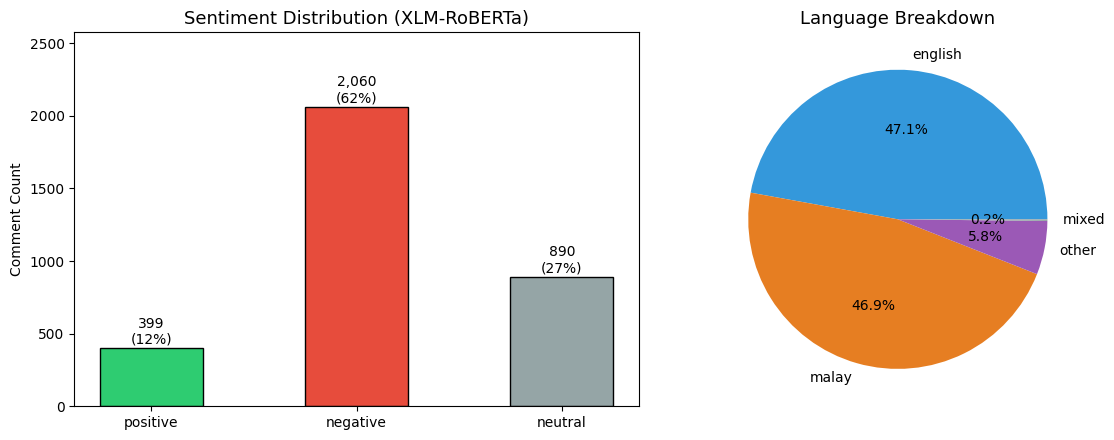

📊 Chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Sentiment distribution
colors = {'positive':'#2ecc71','negative':'#e74c3c','neutral':'#95a5a6'}
labels = ['positive','negative','neutral']
vals   = [dist.get(l,0) for l in labels]
bars = axes[0].bar(labels, vals, color=[colors[l] for l in labels], edgecolor='black', width=0.5)
axes[0].set_title('Sentiment Distribution (XLM-RoBERTa)', fontsize=13)
axes[0].set_ylabel('Comment Count')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                  f'{v:,}\n({v/len(df):.0%})', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(vals)*1.25)

# Language distribution
lang_counts = df['language'].value_counts()
axes[1].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
             colors=['#3498db','#e67e22','#9b59b6','#95a5a6'])
axes[1].set_title('Language Breakdown', fontsize=13)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentiment_distribution_roberta.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## Step 8 — Save Final CSV & Download

Saves the labelled dataset with `cleaned_text`, `language`, `sentiment`, `polarity`,
and the raw class probabilities (`prob_neg`, `prob_neu`, `prob_pos`) alongside the
original metadata columns (likes, replies, video info, etc.).

In [8]:
final_columns = [
    'comment_id','comment_type','author','language',
    'cleaned_text','sentiment','polarity','prob_neg','prob_neu','prob_pos',
    'like_count','reply_count','published_at','video_id','video_title',
]
final_columns = [c for c in final_columns if c in df.columns]
df_final = df[final_columns].copy()

df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f'✅ Cleaned CSV saved → {OUTPUT_CSV}')
print(f'   Rows    : {len(df_final):,}')
print(f'   Columns : {list(df_final.columns)}')
print(f'   Size    : {os.path.getsize(OUTPUT_CSV)/1024:.1f} KB')
df_final.head()

✅ Cleaned CSV saved → /content/output/youtube_comments_cleaned_roberta.csv
   Rows    : 3,349
   Columns : ['comment_id', 'comment_type', 'author', 'language', 'cleaned_text', 'sentiment', 'polarity', 'prob_neg', 'prob_neu', 'prob_pos', 'like_count', 'reply_count', 'published_at', 'video_id', 'video_title']
   Size    : 1190.6 KB


,comment_id,comment_type,author,language,cleaned_text,sentiment,polarity,prob_neg,prob_neu,prob_pos,like_count,reply_count,published_at,video_id,video_title
0,UgwD0xAhOkfF5igvEQF4AaABAg,top_level,@Hasif_Nidzam,english,say subsidi destruct green technolog hail natu...,positive,0.579366,0.130316,0.160001,0.709683,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
1,Ugw66ZF14ReAbgVlgbx4AaABAg,top_level,@asaizanm,english,malaysia realiti far beyong nightmar that,negative,-0.420676,0.543132,0.334412,0.122456,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
2,UgzmIiDCx57h-93MWGB4AaABAg,top_level,@ngrobert5054,english,sinc low pay sohai,neutral,-0.242629,0.358122,0.526385,0.115493,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
3,UgxCaZX3Zc_dUVAH0sh4AaABAg,top_level,@yeongvoonkang1966,english,diesel price jump normalis,neutral,-0.173175,0.266647,0.639880,0.093473,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...
4,UgyzxxHFCcnzvFEFVql4AaABAg,top_level,@maxbuzz4061,english,alot busi seiz golden opportun increas price b...,positive,0.552111,0.096239,0.255410,0.648351,0,0,2025-06-13T00:00:00+00:00,LmfFs0KWJjA,Diesel prices jump over 50% in Malaysia as bla...


In [9]:
from google.colab import files
print('⬇️  Downloading cleaned CSV...')
files.download(OUTPUT_CSV)
print('✅ Done!')
print('\n➡️  Next: Use youtube_comments_cleaned.csv for model training.')

⬇️  Downloading cleaned CSV...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!

➡️  Next: Use youtube_comments_cleaned.csv for model training.


## Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Language Detection | EN / MY / Mixed / Other |
| 2 | Basic Cleaning | URLs, emails, numbers removed |
| 3 | Malay Slang Normalisation | applied |
| 4 | Tokenization | 3+ letter words |
| 5 | Stop Word Removal | EN + MY combined list |
| 6 | Stemming / Lemmatisation | English only (Malay kept as-is) |
| 7 | XLM-RoBERTa Inference | `cardiffnlp/twitter-xlm-roberta-base-sentiment` |
| 8 | Neutral-Shrinking Threshold | `NEUTRAL_CEILING` applied |

Run the cell below for a printed summary with the final counts.

In [10]:
print('=' * 58)
print('  XLM-RoBERTa SENTIMENT LABELLING SUMMARY')
print('=' * 58)
print(f'  Step 1  - Language Detection   : ✅ EN / MY / Mixed / Other')
print(f'  Step 2  - Basic Cleaning       : ✅ URLs, emails, numbers removed')
print(f'  Step 3  - Malay Slang Norm     : ✅ {len(MALAY_SLANG)} slang rules applied')
print(f'  Step 4  - Tokenization         : ✅ 3+ letter words')
print(f'  Step 5  - Stop Word Removal    : ✅ EN+MY ({len(combined_stopwords)} words)')
print(f'  Step 6  - Stem / Lemmatize     : ✅ English only (Malay kept as-is)')
print(f'  Step 7  - XLM-RoBERTa model    : ✅ {MODEL_NAME}')
print(f'  Step 8  - Neutral Ceiling      : ✅ {NEUTRAL_CEILING}')
print('─' * 58)
print(f'  Total comments (final)         : {len(df_final):,}')
pos_n = dist.get('positive',0)
neg_n = dist.get('negative',0)
neu_n = dist.get('neutral',0)
print(f'  Positive                       : {pos_n:,} ({pos_n/len(df_final):.1%})')
print(f'  Negative                       : {neg_n:,} ({neg_n/len(df_final):.1%})')
print(f'  Neutral                        : {neu_n:,} ({neu_n/len(df_final):.1%})')
print('=' * 58)
print('\n✅ Dataset is ready for Model Training!')

  XLM-RoBERTa SENTIMENT LABELLING SUMMARY
  Step 1  - Language Detection   : ✅ EN / MY / Mixed / Other
  Step 2  - Basic Cleaning       : ✅ URLs, emails, numbers removed
  Step 3  - Malay Slang Norm     : ✅ 26 slang rules applied
  Step 4  - Tokenization         : ✅ 3+ letter words
  Step 5  - Stop Word Removal    : ✅ EN+MY (305 words)
  Step 6  - Stem / Lemmatize     : ✅ English only (Malay kept as-is)
  Step 7  - XLM-RoBERTa model    : ✅ cardiffnlp/twitter-xlm-roberta-base-sentiment
  Step 8  - Neutral Ceiling      : ✅ 0.4
──────────────────────────────────────────────────────────
  Total comments (final)         : 3,349
  Positive                       : 399 (11.9%)
  Negative                       : 2,060 (61.5%)
  Neutral                        : 890 (26.6%)

✅ Dataset is ready for Model Training!


In [13]:
# ── Qualitative Check — Top 10 most-confident comments per sentiment class ────
pd.set_option('display.max_colwidth', 150)

for label, prob_col in [('positive', 'prob_pos'), ('negative', 'prob_neg'), ('neutral', 'prob_neu')]:
    print(f'\n{"="*70}')
    print(f'  TOP 30 MOST CONFIDENT "{label.upper()}" COMMENTS')
    print(f'{"="*70}')
    top10 = df[df['sentiment'] == label].sort_values(prob_col, ascending=False).head(30)
    for i, row in enumerate(top10.itertuples(), 1):
        text = str(getattr(row, 'text'))
        prob = getattr(row, prob_col)
        snippet = (text[:120] + '…') if len(text) > 120 else text
        print(f'{i:>2}. [{prob:.3f}] {snippet}')


  TOP 30 MOST CONFIDENT "POSITIVE" COMMENTS
 1. [0.915] Well. A big thanks to Lady Charlotte Parnell - really appreciate her. She's honestly one of the smartest and most suppor…
 2. [0.896] M Charlotte Parnell, has really set the standard for others to follow, we love her here in Ontario Canada M as she has b…
 3. [0.893] Kaya kaya kaya. Alhamdulillah. Tqsm.❤
 4. [0.890] YOU ARE WELCOME GUYS
 5. [0.881] Weekly doom and gloom news by zeit invest.
 6. [0.880] Lol off course  it is good. Even the Singaporeans  loving them.
 7. [0.877] Easy cupcake you deserve it
 8. [0.875] Best comment 👍
 9. [0.873] Afifah.. Mantap sounds hang.. ❤👍👍👍
10. [0.859] Hi teacher Aina, happy weekend. See you in class tomorrow 😉
11. [0.857] Người Malaysia có khả năng sử dụng tiếng Anh lưu loát, thật ngưỡng mộ, from Việt Nam ❤
12. [0.856] Bagus. Padan muka.
13. [0.856] 😁 prefect excuse to visit JB "girl friends"
14. [0.851] PM  Anwar is great and I admire him. He always find answers for the citixens of Malaysia.